
--------------
# Image Segmentation, Feature Detection, Description, and Matching

## Part 1: Image Segmentation
This section compares:
- Classical Method: **Thresholding**
- Machine Learning Method: **K-means Clustering**

## Part 2: Feature Descriptor Analysis
-  **HOG (Histogram of gradient)**




### Install required library:



In [ ]:
!pip install scikit-image

### Import libraries:

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure

### Upload Images:

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving image1.jpg to image1.jpg
Saving image2.jpg to image2.jpg


### Read and Convert images into grayscale:

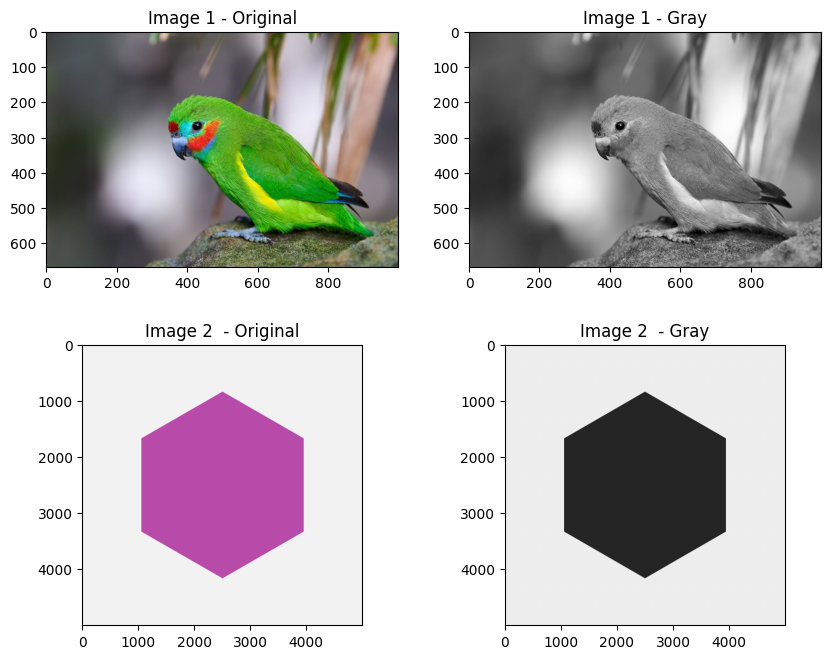

In [ ]:
img1 = cv2.imread('image1.jpg')
img2 = cv2.imread('image2.jpg')

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))

# Image 1
plt.subplot(2,2,1)
plt.title("Image 1 - Original")
plt.imshow(img1_rgb, cmap='gray')

plt.subplot(2,2,2)
plt.title("Image 1 - Gray")
plt.imshow(gray1, cmap='gray')

# Image 2
plt.subplot(2,2,3)
plt.title("Image 2  - Original")
plt.imshow(img2_rgb, cmap='gray')

plt.subplot(2,2,4)
plt.title("Image 2  - Gray")
plt.imshow(gray2, cmap='gray')
plt.show()

# **Part 1 — Image Segmentation**

### **1.1 Definition**
> Image segmentation is the process of dividing an image into **meaningful regions or objects.**

### **1.2 Classical Segmentation: Thresholding**
> **Thresholding** converts a grayscale image into a binary image by separating pixels into foreground and background using a **threshold value.**


### **Steps:**
> 1. Convert image to grayscale.
2. Choose a threshold value.
3. Assign pixels above the threshold to one class and the rest to another.
4. Display the result.

### **Code & Result:**










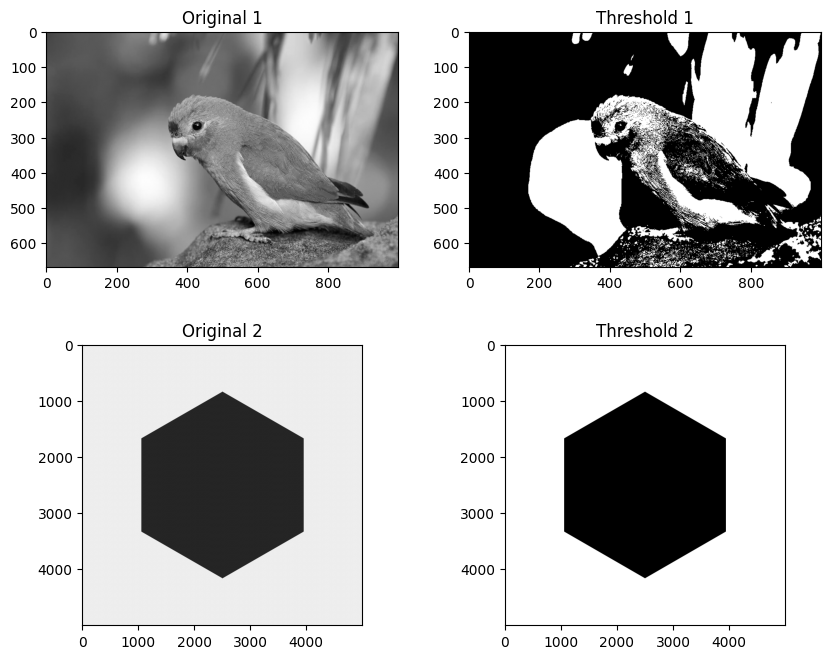

In [ ]:
_, th1 = cv2.threshold(gray1, 127, 255, cv2.THRESH_BINARY)

_, th2 = cv2.threshold(gray2, 127, 255, cv2.THRESH_BINARY)


plt.figure(figsize=(10,8))

# Image 1
plt.subplot(2,2,1)
plt.title("Original 1")
plt.imshow(gray1, cmap='gray')

plt.subplot(2,2,2)
plt.title("Threshold 1")
plt.imshow(th1, cmap='gray')

# Image 2
plt.subplot(2,2,3)
plt.title("Original 2")
plt.imshow(gray2, cmap='gray')

plt.subplot(2,2,4)
plt.title("Threshold 2")
plt.imshow(th2, cmap='gray')

plt.show()

### **Thresholding:**
> - **Simple** and **fast**.
> - Works well when the **foreground and background have clear intensity differences** (as shown in Image 2).
> - Its limitation is that it performs poorly when lighting is uneven or object intensity **overlaps** with the background (as shown in Image 1).

### **1.3 ML-Based Segmentation: K-means**
> K-means is an **unsupervised learning** method that groups pixels into clusters based on similarity in their feature space, such as color, intensity, or texture.

### **Steps**:

> 1. Prepare feature vectors for pixels.
2. Choose the number of clusters \(k\).
3. Run the K-means algorithm to assign each pixel to the nearest cluster center.
4. Update the cluster centers until convergence.
5. Reshape the cluster labels into an image mask.

### **Code & Result:**


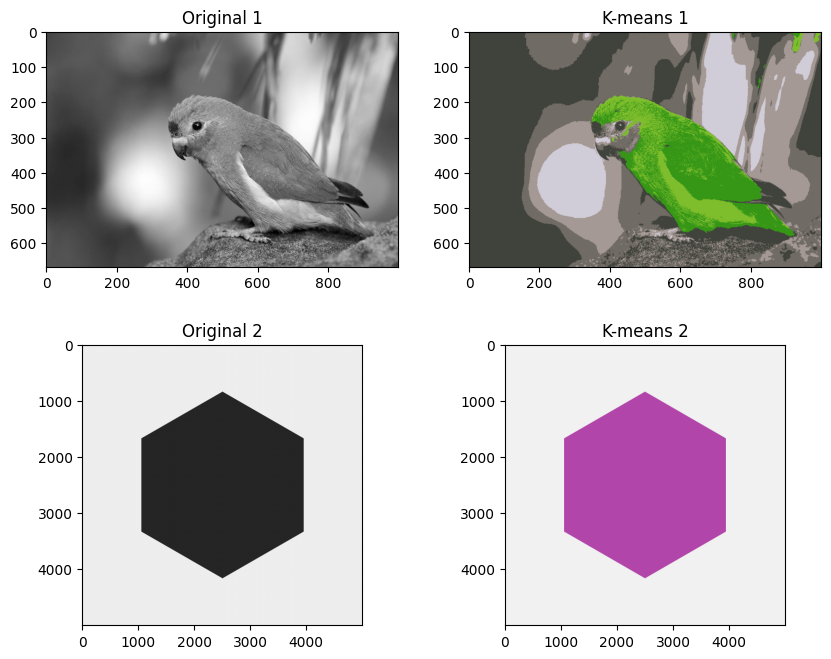

In [ ]:
def kmeans_seg(img,k):
    Z = img.reshape((-1,3))
    Z = np.float32(Z)

    K = k
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

    _, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    center = np.uint8(center)
    res = center[label.flatten()]
    return res.reshape((img.shape))

km1 = kmeans_seg(img1,6)
km2 = kmeans_seg(img2,2)

plt.figure(figsize=(10,8))

# Image 1
plt.subplot(2,2,1)
plt.title("Original 1")
plt.imshow(gray1, cmap='gray')

plt.subplot(2,2,2)
plt.title("K-means 1")
plt.imshow(cv2.cvtColor(km1, cv2.COLOR_BGR2RGB))

# Image 2
plt.subplot(2,2,3)
plt.title("Original 2")
plt.imshow(gray2, cmap='gray')

plt.subplot(2,2,4)
plt.title("K-means 2")
plt.imshow(cv2.cvtColor(km2, cv2.COLOR_BGR2RGB))

plt.show()

### **K-means:**
> - It does **not** require labeled examples.
> - It is more flexible than thresholding.
> - It segments the image by grouping similar pixels into meaningful clusters.

### **1.4 Discussion**

> **Thresholding** works best when the image histogram has **two** clearly separated groups. **K-means** is more **flexible** because it groups pixels into clusters based on similarity in features such as intensity and position. Thresholding is easier to explain, while K-means provides a more adaptable framework for complex segmentation tasks.










### **1.5 Comparison**
 | Method |Strengths | Limitations |  |
|---|---|---|---|
| Thresholding  | Fast, simple and easy to implement | Sensitive to overlapping intensities |
| K-means  | Flexible and useful for complex images | Requires choosing the number of clusters  |




# **Part 2 — HOG Descriptor**

### **2.1 Definition**

> Histogram of Oriented Gradients (HOG) is a feature descriptor that represents an image by counting gradient orientations in local regions.



### **2.2 Main Idea**

> HOG captures shape and edge structure rather than raw pixel values. It is useful because object shape often remains more stable than pixel brightness.



### **Steps:**

> 1. Convert the image to grayscale.
2. Compute gradients in each local region.
3. Build orientation histograms.
4. Normalize blocks to reduce illumination effects.
5. Flatten the result into a descriptor vector.



### **Why HOG?**


> - Good for shape-based representation.
> - It is less affected by lighting changes than raw pixels.
> - Useful for comparing the original image and transformed versions.

### **Code & Result:**







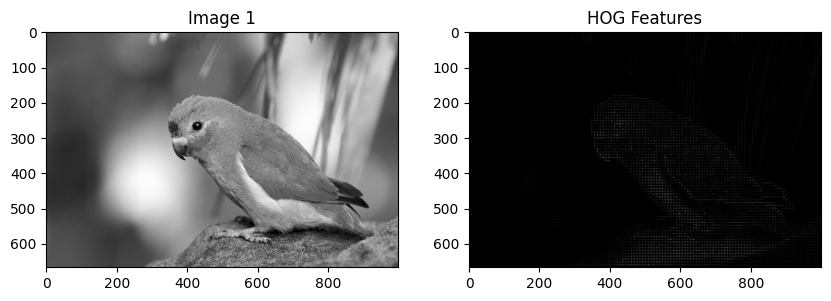

In [ ]:
#HOG function
def get_hog(img):
    features, hog_img = hog(img,
                            orientations=9,
                            pixels_per_cell=(8, 8),
                            cells_per_block=(2, 2),
                            visualize=True)
    return hog_img

(h, w) = gray1.shape
center = (w//2, h//2)

hog_original = get_hog(gray1)

plt.figure(figsize=(10,8))

plt.subplot(1,2,1)
plt.title("Image 1")
plt.imshow(gray1, cmap='gray')

plt.subplot(1,2,2)
plt.title('HOG Features')
plt.imshow(hog_original, cmap='gray')

plt.show()



### **2.3 Robustness Test**


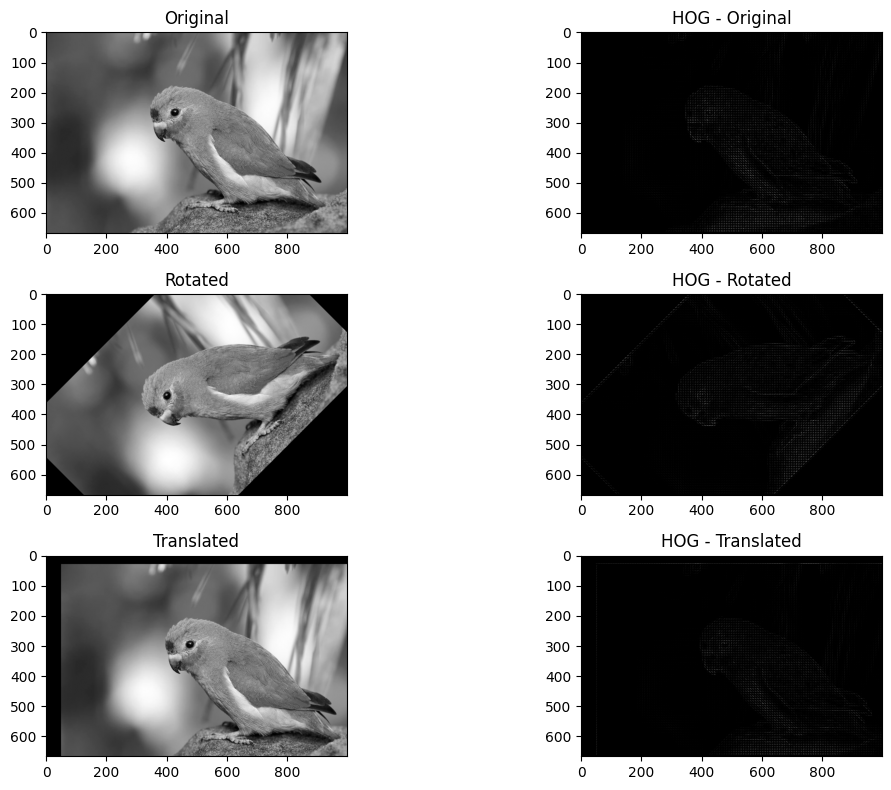

In [ ]:
# Rotation
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(gray1, M, (w, h))

# Translation
M2 = np.float32([[1, 0, 50], [0, 1, 30]])
translated = cv2.warpAffine(gray1, M2, (w, h))

# HOG Images
hog_original = get_hog(gray1)
hog_rotated = get_hog(rotated)
hog_translated = get_hog(translated)


plt.figure(figsize=(12, 8))

# Original
plt.subplot(3, 2, 1)
plt.title('Original')
plt.imshow(gray1, cmap='gray')

plt.subplot(3, 2, 2)
plt.title('HOG - Original')
plt.imshow(hog_original, cmap='gray')

# Rotated
plt.subplot(3, 2, 3)
plt.title('Rotated')
plt.imshow(rotated, cmap='gray')

plt.subplot(3, 2, 4)
plt.title('HOG - Rotated')
plt.imshow(hog_rotated, cmap='gray')

# Translated
plt.subplot(3, 2, 5)
plt.title('Translated')
plt.imshow(translated, cmap='gray')

plt.subplot(3, 2, 6)
plt.title('HOG - Translated')
plt.imshow(hog_translated, cmap='gray')

plt.tight_layout()
plt.show()

### **2.4 Discussion**
HOG captures edge directions and is useful for shape recognition. It is relatively stable under translation but sensitive to rotation, since rotating the image changes edge orientations. Despite these changes, HOG can still represent the overall structure of objects.





### **Conclusion**
Thresholding is a simple classical segmentation method, while K-means provides a more flexible clustering-based approach for image segmentation. HOG is a strong descriptor for capturing shape and gradient information.